In [2]:
import pandas as pd
df = pd.read_csv("sales_visualization_data.csv")

In [2]:
df

,Date,Product,Region,Quantity,UnitPrice,CustomerAge,Rating,Revenue,Month,Quarter
0,2024-04-12,Laptop,East,4,899,37,4.0,3596,4,2
1,2024-12-14,Charger,Central,1,599,46,3.5,599,12,4
2,2024-09-27,Headphones,Central,12,599,62,3.5,7188,9,3
3,2024-04-16,Monitor,South,1,49,63,5.0,49,4,2
4,2024-03-12,Monitor,West,10,299,27,4.0,2990,3,1
...,...,...,...,...,...,...,...,...,...,...
295,2024-06-11,Mouse,South,14,149,19,5.0,2086,6,2
296,2024-07-26,Keyboard,West,8,79,50,4.0,632,7,3
297,2024-06-17,Webcam,East,3,1299,50,3.5,3897,6,2
298,2024-06-09,Webcam,West,2,1299,58,5.0,2598,6,2


In [4]:
df.describe()

,Quantity,UnitPrice,CustomerAge,Rating,Revenue,Month,Quarter
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,7.406667,364.700000,41.296667,4.256667,2794.226667,6.696667,2.560000
std,4.066499,378.086862,13.168143,0.552394,3557.165815,3.310769,1.050434
min,1.000000,19.000000,18.000000,3.500000,19.000000,1.000000,1.000000
25%,4.000000,79.000000,30.000000,4.000000,395.000000,4.000000,2.000000
50%,7.500000,149.000000,42.000000,4.000000,1131.500000,7.000000,3.000000
75%,11.000000,599.000000,52.000000,4.625000,4186.000000,9.000000,3.000000
max,14.000000,1299.000000,64.000000,5.000000,18186.000000,12.000000,4.000000


In [5]:
df.head(10)

,Date,Product,Region,Quantity,UnitPrice,CustomerAge,Rating,Revenue,Month,Quarter
0,2024-04-12,Laptop,East,4,899,37,4.0,3596,4,2
1,2024-12-14,Charger,Central,1,599,46,3.5,599,12,4
2,2024-09-27,Headphones,Central,12,599,62,3.5,7188,9,3
3,2024-04-16,Monitor,South,1,49,63,5.0,49,4,2
4,2024-03-12,Monitor,West,10,299,27,4.0,2990,3,1
5,2024-07-07,Keyboard,South,14,599,60,4.0,8386,7,3
6,2024-01-21,Tablet,West,6,49,51,4.5,294,1,1
7,2024-04-12,Laptop,West,5,899,43,4.0,4495,4,2
8,2024-05-01,Laptop,Central,14,1299,58,4.0,18186,5,2
9,2024-08-02,Tablet,North,11,299,20,4.5,3289,8,3


#### Date: Transaction date
#### Product: Product name (Laptop, Phone, Tablet, etc.)
#### Region: Sales region (North, South, East, West, Central)
#### Quantity: Number of units sold
#### UnitPrice: Price per unit
#### CustomerAge: Age of the customer
#### Rating: Product rating (3.5 to 5.0)
#### Revenue: Total revenue (Quantity × UnitPrice)
#### Month: Month number (1-12)
#### Quarter: Quarter number (1-4)

In [6]:
! pip install Matplotlib

#### Basic Line Plot
#### Create a line plot showing the total revenue per month for the year 2024.
#### X-axis: Month
#### Y-axis: Total Revenue
#### Add appropriate labels and title
#### Add a grid for better readability

In [11]:
Total_revenue = df.groupby('Month').agg({'Revenue':'sum'})

In [12]:
Total_revenue

,Revenue
Month,
1,23623
2,93968
3,42925
4,65537
5,103370
6,53143
7,86507
8,95148
9,74194


In [14]:
Total_revenue.index

Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], dtype='int64', name='Month')

In [15]:
Total_revenue.values

array([[ 23623],
       [ 93968],
       [ 42925],
       [ 65537],
       [103370],
       [ 53143],
       [ 86507],
       [ 95148],
       [ 74194],
       [ 54171],
       [ 62756],
       [ 82926]])

In [17]:
plt.xticks?

Signature:
plt.xticks(
    ticks: 'ArrayLike | None' = None,
    labels: 'Sequence[str] | None' = None,
    *,
    minor: 'bool' = False,
    **kwargs,
) -> 'tuple[list[Tick] | np.ndarray, list[Text]]'
Docstring:
Get or set the current tick locations and labels of the x-axis.

Pass no arguments to return the current values without modifying them.

Parameters
----------
ticks : array-like, optional
    The list of xtick locations.  Passing an empty list removes all xticks.
labels : array-like, optional
    The labels to place at the given *ticks* locations.  This argument can
    only be passed if *ticks* is passed as well.
minor : bool, default: False
    If ``False``, get/set the major ticks/labels; if ``True``, the minor
    ticks/labels.
**kwargs
    `.Text` properties can be used to control the appearance of the labels.

    .. warning::

        This only sets the properties of the current ticks, which is
        only sufficient if you either pass *ticks*, resulting in a
        f

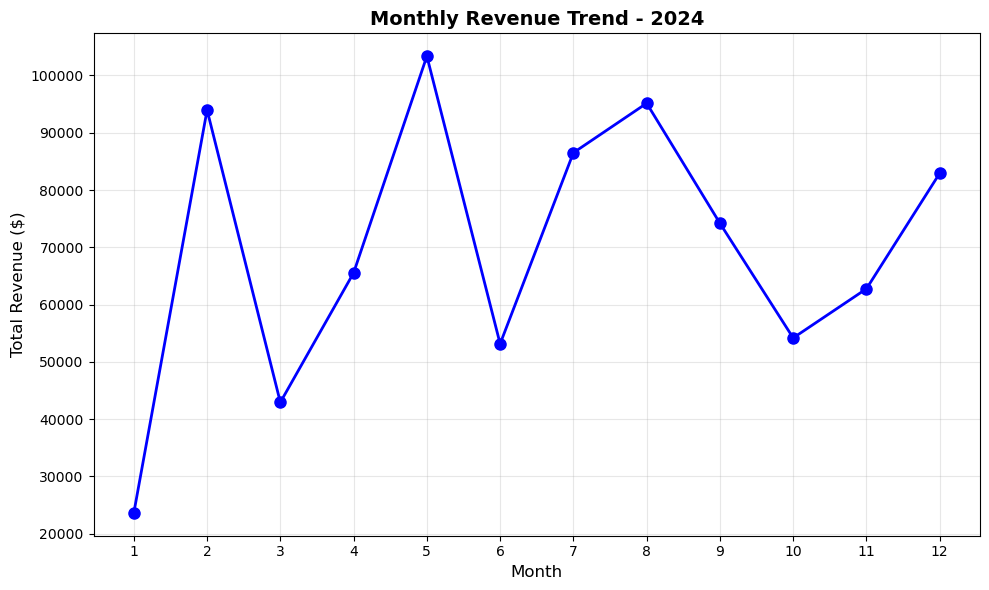

In [13]:
# Create line plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(Total_revenue.index, Total_revenue.values, marker='o', linewidth=2, markersize=8, color='blue')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.title('Monthly Revenue Trend - 2024', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

### monthly revenue trends for the top 3 products

In [16]:
monthly_revenue = df.groupby(['Month','Product']).agg({'Revenue':'sum'}).reset_index()

In [20]:
top_product = monthly_revenue.nlargest(3,'Revenue')

In [21]:
top_product

,Month,Product,Revenue
69,8,Laptop,29094
86,10,Charger,28506
111,12,Webcam,25236


In [22]:
top3_products = df.groupby('Product')['Revenue'].sum().nlargest(3).index

In [23]:
top3_products

Index(['Laptop', 'Webcam', 'Charger'], dtype='object', name='Product')

### Multiple line chart
#### Plot the monthly/overall revenue trends for the top 3 products on the same chart.
#### Use different colors and line styles for each product
#### Add a legend
#### Include markers on the lines
#### Add title, labels, and grid

In [24]:
top3_products = df.groupby('Product')['Revenue'].sum().nlargest(3).index

In [25]:
top3_products

Index(['Laptop', 'Webcam', 'Charger'], dtype='object', name='Product')

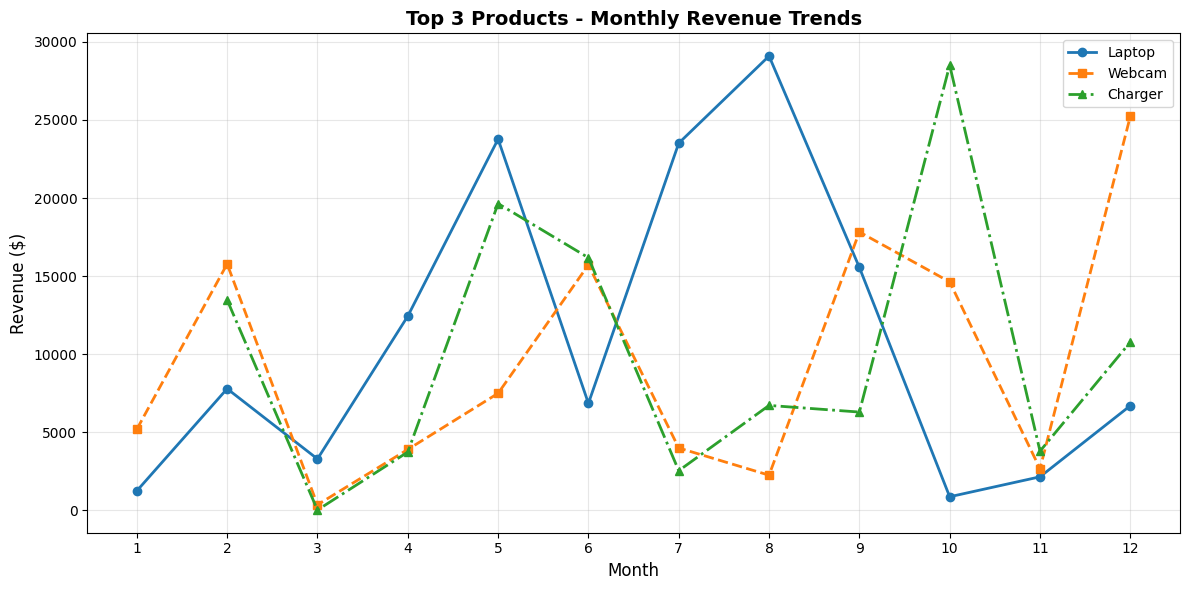

In [34]:
#Plot the graph
plt.figure(figsize=(12, 6))
line_styles = ['-', '--', '-.']
markers = ['o', 's', '^']
for i, product in enumerate(top3_products):
    product_data = df[df['Product'] == product].groupby('Month')['Revenue'].sum()
    plt.plot(product_data.index, product_data.values, label=product, linewidth=2, linestyle=line_styles[i], marker=markers[i], markersize=6)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.title('Top 3 Products - Monthly Revenue Trends', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

### Barchart for Products
#### Create a horizontal bar chart showing the total revenue for each product.
#### Sort the products by revenue in descending order
#### Use different colors for each barAdd data labels on each bar
#### Add a title and axis labels

In [19]:
product_revenue = df.groupby('Product')['Revenue'].sum().sort_values(ascending = False)
product_revenue

Product
Laptop        133261
Webcam        115034
Charger       111666
Keyboard       89775
Tablet         75283
Headphones     74478
Mouse          73422
Phone          68833
Speaker        64247
Monitor        32269
Name: Revenue, dtype: int64

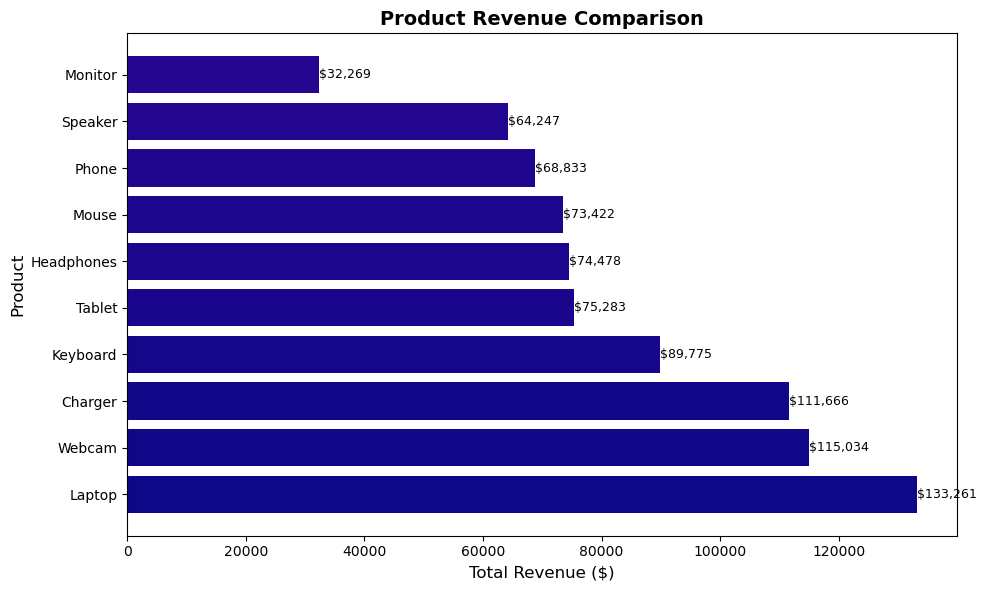

In [20]:
# Create horizontal bar chart
plt.figure(figsize=(10, 6))
colors = plt.cm.plasma(range(len(product_revenue)))
bars = plt.barh(product_revenue.index, product_revenue.values, color=colors)
# Add data labels
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,f'${width:,.0f}', ha='left', va='center', fontsize=9)
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.title('Product Revenue Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

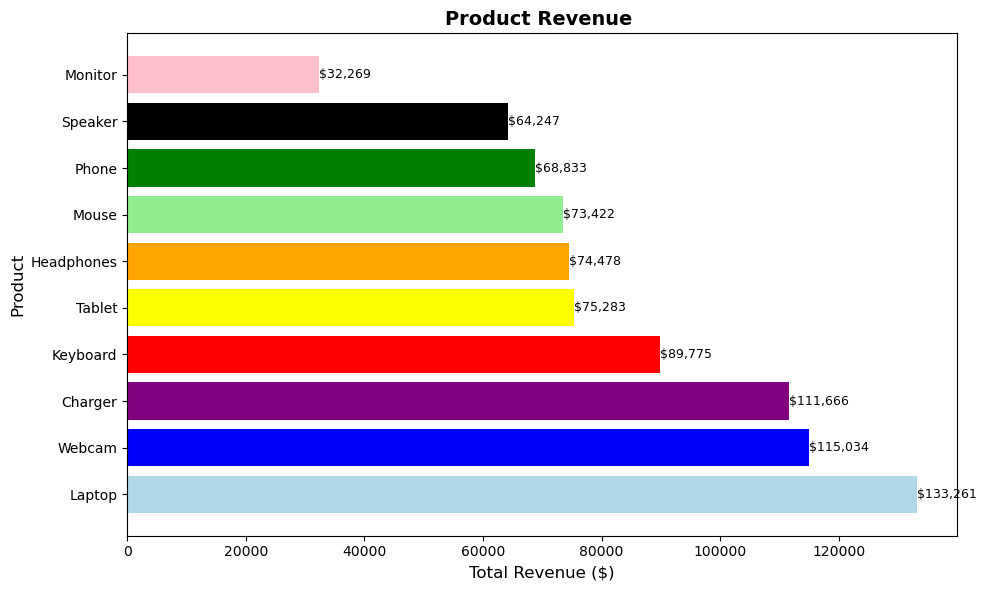

In [21]:
# Create horizontal bar chart
plt.figure(figsize=(10, 6))
colors = ['lightblue', 'blue', 'purple', 'red', 'yellow', 'orange', 'lightgreen', 'green', 'black', 'pink']
bars = plt.barh(product_revenue.index, product_revenue.values, color=colors)
# Add data labels
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,f'${width:,.0f}', ha='left', va='center', fontsize=9)
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.title('Product Revenue ', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Customized Bar Plot
#### Create a bar chart comparing total quantity sold across all 5 regions.
#### Customize the bar colors
#### Rotate x-axis labels if needed
#### Add a title "Regional Sales Performance"
#### Save the chart as 'regional_sales.png'

In [61]:
total_quantity = df.groupby('Region')['Quantity'].sum()

In [62]:
total_quantity

Region
Central    467
East       435
North      455
South      446
West       419
Name: Quantity, dtype: int64

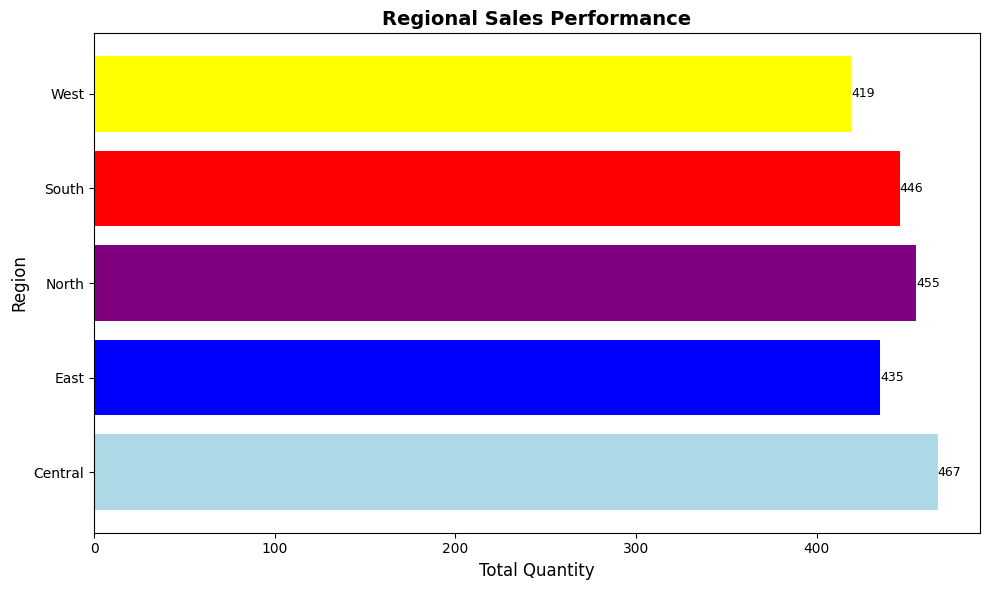

In [66]:
plt.figure(figsize=(10, 6))
colors = ['lightblue', 'blue', 'purple', 'red', 'yellow', 'orange', 'lightgreen', 'green', 'black', 'pink']
bars = plt.barh(total_quantity.index, total_quantity.values, color=colors)
# Add data labels
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,f'{width:,.0f}', ha='left', va='center', fontsize=9)
plt.xlabel('Total Quantity', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.title('Regional Sales Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

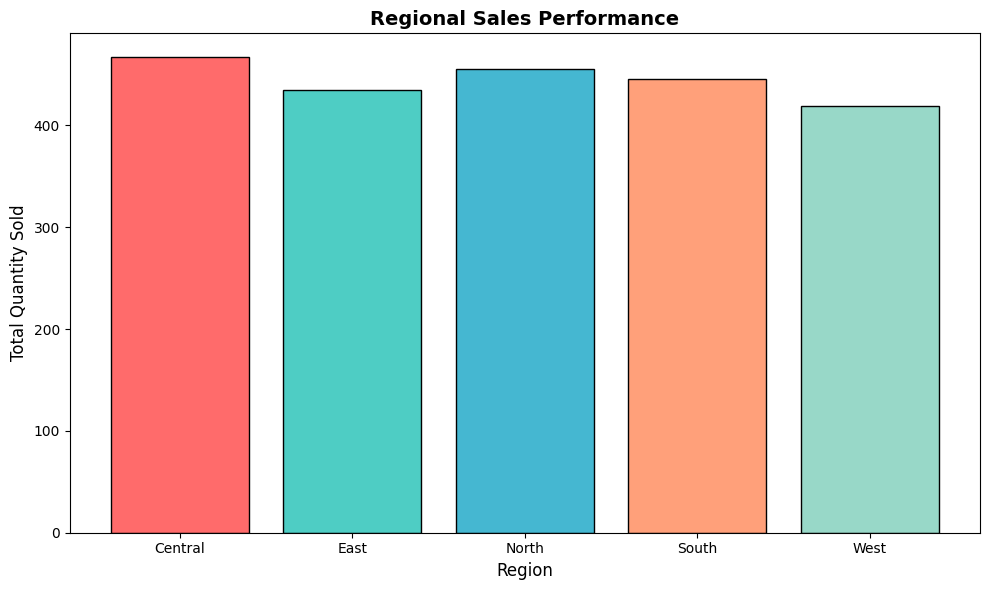

Chart saved as 'regional_sales.png'


In [65]:
# Create bar chart
plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
plt.bar(total_quantity.index, total_quantity.values, color=colors, edgecolor='black')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Quantity Sold', fontsize=12)
plt.title('Regional Sales Performance', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
# Save the chart
plt.savefig('regional_sales.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart saved as 'regional_sales.png'")

### Create a figure with 2 subplots:
#### Subplot 1: Monthly revenue (line plot)
#### Subplot 2: Top 5 products by revenue (bar plot)
#### Both should have proper titles and labels

In [71]:
Subplot1_data = df.groupby('Month')['Revenue'].sum()

In [72]:
Subplot1_data

Month
1      23623
2      93968
3      42925
4      65537
5     103370
6      53143
7      86507
8      95148
9      74194
10     54171
11     62756
12     82926
Name: Revenue, dtype: int64

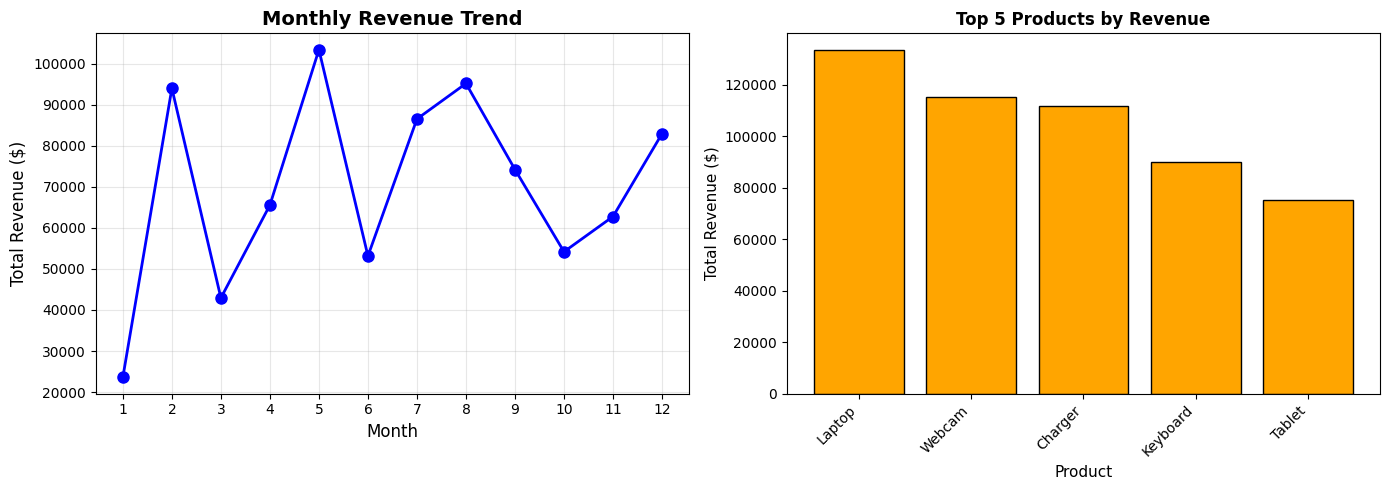

In [78]:
# Create line plot
# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(Subplot1_data.index, Subplot1_data.values, marker='o', linewidth=2, markersize=8, color='blue')
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Total Revenue ($)', fontsize=12)
ax1.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(1, 13))
#ax1.tight_layout()
#ax1.show()
top5_products = df.groupby('Product')['Revenue'].sum().nlargest(5)
ax2.bar(range(len(top5_products)), top5_products.values, color='orange', edgecolor='black')
ax2.set_xticks(range(len(top5_products)))
ax2.set_xticklabels(top5_products.index, rotation=45, ha='right')
ax2.set_xlabel('Product', fontsize=11)
ax2.set_ylabel('Total Revenue ($)', fontsize=11)
ax2.set_title('Top 5 Products by Revenue', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

AttributeError: 'int' object has no attribute 'strftime'

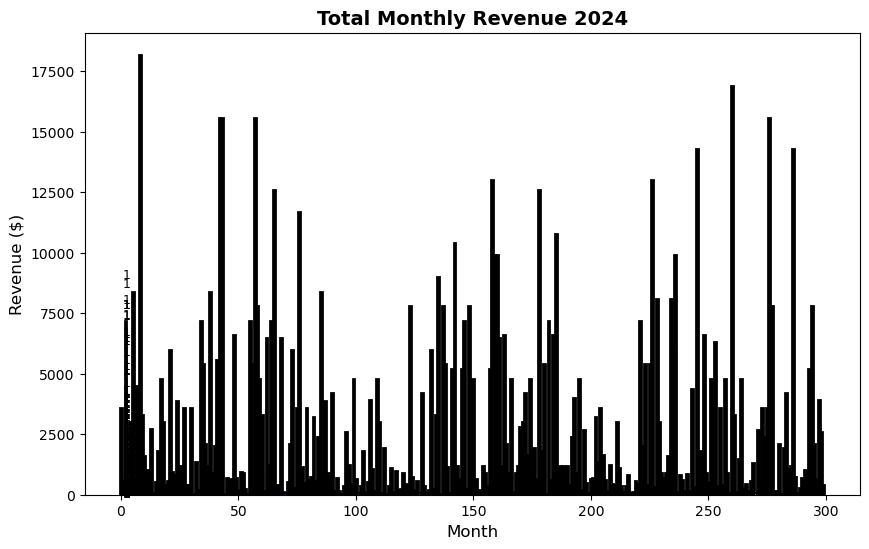

In [4]:
# Customized bar chart
import matplotlib.pyplot as plt
colors=plt.cm.plasma(range(len(df)))
plt.figure(figsize=(10,6))
bars=plt.bar(range(len(df)),df['Revenue'],color=colors,edgecolor='black',linewidth=2)
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_x() + bar.get_height()/2,f'{width:,.0f}', ha='left', va='center', fontsize=9)
plt.title('Total Monthly Revenue 2024', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(range(len(df)), [d.strftime('%B') for d in df['Month']], rotation=45)
plt.tight_layout()
plt.show()